In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv


In [2]:
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Shape:", df.shape)
print(df.columns.tolist())
df.head()

Shape: (7043, 21)
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Overall Churn Rate (%):
 Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

Churn Rate by Contract Type (%):
 Contract
Month-to-month    42.709677
One year          11.277174
Two year           2.848665
Name: Churn, dtype: float64

Churn Rate by Tenure Group (%):
 Tenure Group
0-1 yr     47.678161
1-3 yrs    25.538793
3-6 yrs    11.929357
Name: Churn, dtype: float64

Avg Monthly Charges (Churned vs Retained):
 Churn
No     61.307408
Yes    74.441332
Name: MonthlyCharges, dtype: float64


/tmp/ipykernel_17/3853788307.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_by_tenure = df.groupby('Tenure Group')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)


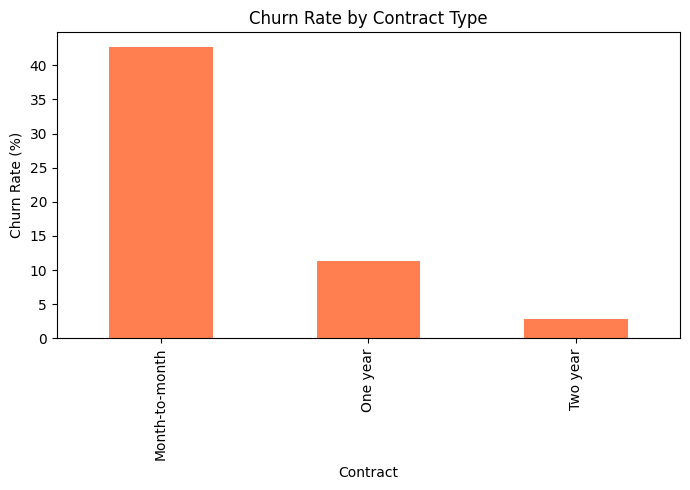

In [3]:
import matplotlib.pyplot as plt
df.columns = df.columns.str.strip()
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(subset=['TotalCharges'], inplace=True)
df.drop_duplicates(inplace=True)

# Overall churn rate
churn_rate = df['Churn'].value_counts(normalize=True) * 100
print("Overall Churn Rate (%):\n", churn_rate)

# Churn by contract type
churn_by_contract = df.groupby('Contract')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
print("\nChurn Rate by Contract Type (%):\n", churn_by_contract)

# Churn by tenure group
df['Tenure Group'] = pd.cut(df['tenure'], bins=[0, 12, 36, 72], labels=['0-1 yr', '1-3 yrs', '3-6 yrs'])
churn_by_tenure = df.groupby('Tenure Group')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
print("\nChurn Rate by Tenure Group (%):\n", churn_by_tenure)

# Average monthly charges: churned vs retained
avg_charges = df.groupby('Churn')['MonthlyCharges'].mean()
print("\nAvg Monthly Charges (Churned vs Retained):\n", avg_charges)

# Chart: churn by contract
plt.figure(figsize=(7,5))
churn_by_contract.plot(kind='bar', color='coral')
plt.title('Churn Rate by Contract Type')
plt.ylabel('Churn Rate (%)')
plt.tight_layout()
plt.savefig('churn_by_contract.png')
plt.show()